In [1]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
#ejemplo moneda
seed = 42
p_true = 0.45
N = 100

datos = np.random.binomial(n=1,p=p_true,size=N)
print(datos)

with pm.Model() as modelo_moneda:
    p = pm.Uniform("p",0,1)

    chain = pm.Bernoulli("X",p,observed=datos)

    idata = pm.sample(draws=2000,tune=2000,chains=4,cores=1,progressbar=False)

Initializing NUTS using jitter+adapt_diag...


[0 0 1 0 0 1 1 0 0 1 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 1 0 1 0 1 1 0 1 0 1 0 1 0 1 1 0 0 1 1 1 1
 0 1 0 0 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1 0 0 0 0 1 1]


Sequential sampling (4 chains in 1 job)
NUTS: [p]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4 seconds.


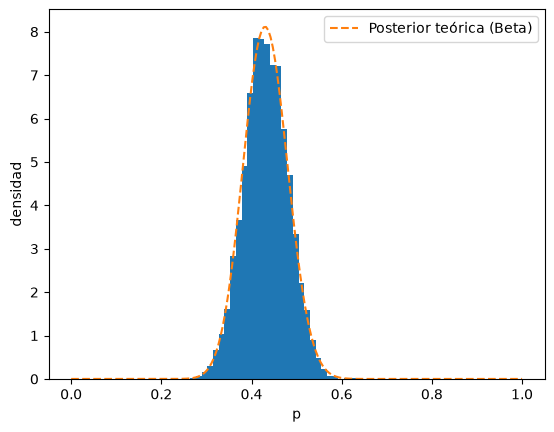

In [30]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

muestras_p = idata.posterior["p"].values.flatten()

# KDE de las muestras (lo que ya teníamos)
kde = stats.gaussian_kde(muestras_p)
x = np.linspace(0, 1, 200)

# Beta teórica: prior Beta(1,1) + datos binomiales -> posterior Beta(1+caras, 1+cecas)
caras = datos.sum()
cecas = len(datos) - caras
beta_teorica = stats.beta(1 + caras, 1 + cecas)

plt.hist(idata.posterior["p"].values.flatten(),bins=30, density=True)
plt.plot(x, beta_teorica.pdf(x), label="Posterior teórica (Beta)", linestyle="--")
plt.xlabel("p")
plt.ylabel("densidad")
plt.legend()
plt.show()

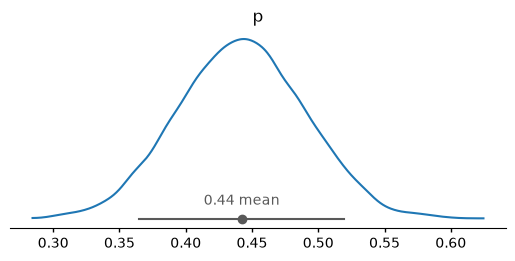

In [28]:
import arviz_plots as azp

azp.plot_dist(idata, var_names=["p"], group="posterior")

In [4]:
import arviz as az
print(az.__version__)

1.2.0


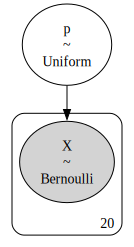

In [3]:
pm.model_to_graphviz(modelo_moneda)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p]
Sampling 2 chains for 1_000 tune and 1_000 d

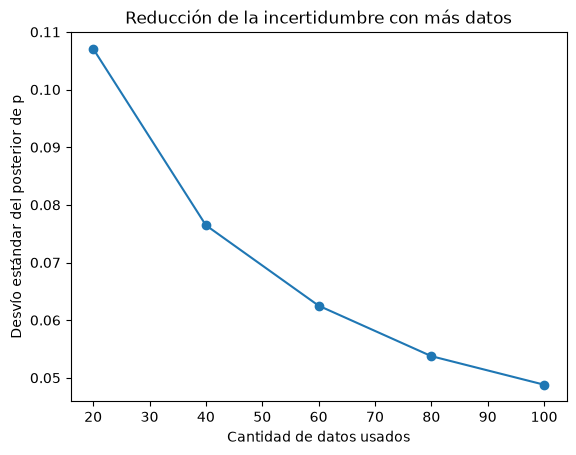

In [31]:
import numpy as np
import matplotlib.pyplot as plt

p_true = 0.45
N = 100
n_bloques = 5
tam_bloque = N // n_bloques        # 20 datos por bloque

datos = np.random.binomial(n=1, p=p_true, size=N)

stds = []
n_datos_usados = []

for i in range(1, n_bloques + 1):
    datos_acumulados = datos[: i * tam_bloque]     # todo lo visto hasta el bloque i

    with pm.Model() as modelo:
        p = pm.Uniform("p", 0, 1)
        X = pm.Bernoulli("X", p, observed=datos_acumulados)
        idata = pm.sample(draws=1000, tune=1000, chains=2, cores=1, progressbar=False)

    stds.append(idata.posterior["p"].values.std())
    n_datos_usados.append(len(datos_acumulados))

plt.plot(n_datos_usados, stds, marker="o")
plt.xlabel("Cantidad de datos usados")
plt.ylabel("Desvío estándar del posterior de p")
plt.title("Reducción de la incertidumbre con más datos")
plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [p]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [p]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [p]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [p]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [p]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


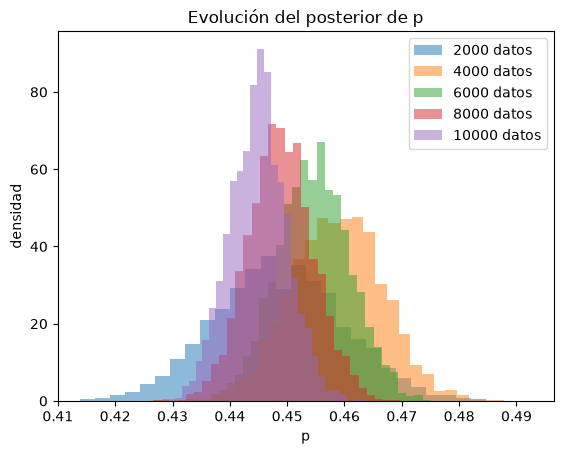

In [35]:
import numpy as np
import matplotlib.pyplot as plt

p_true = 0.45
N = 10000
n_bloques = 5
tam_bloque = N // n_bloques

datos = np.random.binomial(n=1, p=p_true, size=N)

plt.figure()

for i in range(1, n_bloques + 1):
    datos_acumulados = datos[: i * tam_bloque]

    with pm.Model() as modelo:
        p = pm.Uniform("p", 0, 1)
        X = pm.Bernoulli("X", p, observed=datos_acumulados)
        idata = pm.sample(draws=1000, tune=1000, chains=4, cores=1, progressbar=False)

    muestras_p = idata.posterior["p"].values.flatten()
    plt.hist(muestras_p, bins=30, density=True, alpha=0.5,
              label=f"{len(datos_acumulados)} datos")

plt.xlabel("p")
plt.ylabel("densidad")
plt.legend()
plt.title("Evolución del posterior de p")
plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p]
Sampling 2 chains for 1_000 tune and 1_000 d

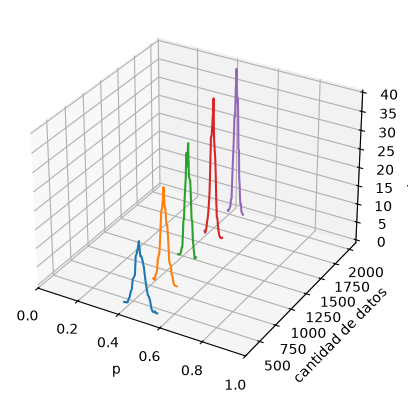

In [39]:
import numpy as np
import matplotlib.pyplot as plt

p_true = 0.45
N = 2000
n_bloques = 5
tam_bloque = N // n_bloques

datos = np.random.binomial(n=1, p=p_true, size=N)

fig = plt.figure()
ax = fig.add_subplot(projection="3d")

for i in range(1, n_bloques + 1):
    datos_acumulados = datos[: i * tam_bloque]

    with pm.Model() as modelo:
        p = pm.Uniform("p", 0, 1)
        X = pm.Bernoulli("X", p, observed=datos_acumulados)
        idata = pm.sample(draws=1000, tune=1000, chains=2, cores=1, progressbar=False)

    muestras_p = idata.posterior["p"].values.flatten()
    alturas, bordes = np.histogram(muestras_p, bins=30, density=True)
    centros = (bordes[:-1] + bordes[1:]) / 2   # centro de cada barra del histograma

    ax.plot(centros, alturas, zs=len(datos_acumulados), zdir="y")

ax.set_xlabel("p")
ax.set_xlim(0,1)
ax.set_ylabel("cantidad de datos")
ax.set_zlabel("densidad")
plt.show()